# 02 · Post-Mortem Analysis — LineWise DAMM
**Objetivo**: Detectar qué secuencias históricas degradaron el OEE en las líneas 14, 17 y 19,
cuantificar el coste en HL perdidos y explicar las causas mediante grafos dirigidos.

**Granularidad**: semanal (ISO week). El análisis se centra en transiciones entre OFs
dentro de la misma semana y línea.

> Este notebook usa la clase `PostMortemAnalyzer` de `post_mortem.py`.

## 0 · Modelo de datos operativo: OF/MES como nexo

Este notebook sigue la arquitectura de datos de planta: la OF/MES es el nexo entre cambios, OEE, volumen y tiempos. La lectura operativa clave es que un cambio no vive aislado: para clasificarlo y medir su efecto hay que revisar la OF anterior en la misma linea y ventana temporal.

```mermaid
flowchart LR
    CF["Cambio formato"] -.-> TCT["Tiempo cambio teorico"]
    ML["Mantenimiento y limpiezas"] -.-> TCT
    TCT <--> OF["MES / OF (nexo)"]
    CAM["Cambios"] -.-> OF
    CAM --> TC["Tipo de cambio"]
    TC --> PREV["Revisar OF anterior"]
    OF -.-> OEE["OEE"]
    OF -.-> T["Tiempo"]
    OF -.-> V["Volumen"]
    OEE --> CYN["Cambio si/no"]
    OEE --> KPI["%OEE / %Rendimiento"]
    V --> V2["HL / UDS / OEE"]
    T --> T2["H Tot / Par Tot / PNP / Limpieza / Idle / %Disp / %Calidad / %Rend"]
```

Formulas usadas como control semantico:

- `OEE = Disponibilidad x Rendimiento x Calidad`
- `Disponibilidad = Tiempo funcionamiento / Tiempo planificado`
- `Rendimiento = (Tiempo ciclo ideal x Produccion total) / Tiempo funcionamiento`
- `Calidad = Produccion buena / Produccion total`
- `Tiempo cambio = H Tot - (PNP + Limpieza + Idle)`; `Idle` se separa para no imputarlo automaticamente al OEE.

En el post-mortem, `CAMBIOS -> Tipo de cambio -> Revisar OF anterior` se materializa con `sku_prev`, `marca_prev`, `envase_prev` y `tipo_transicion`.


In [62]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from pathlib import Path

from analisis_postmorten.post_mortem import PostMortemAnalyzer
from analisis_postmorten.data_loaders import load_all_operations

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
DATA_DIR = Path('../OPERACIONS')

## 1 · Carga de datos desde OF/MES como nexo comun

In [63]:
dfs = load_all_operations(DATA_DIR)
df_oee  = dfs['oee']
df_cam  = dfs['cam']
df_mant = dfs['mant']
df_tiem = dfs['tiem']
df_vol  = dfs['vol']

print("Datos cargados")
print(f"  OEE: {len(df_oee)} OFs | tren unicos: {sorted(df_oee['tren'].unique())}")
print(f"  Cambios: {len(df_cam)} | Mantenimiento: {len(df_mant)}")

for name, df in {'OEE': df_oee, 'Cambios': df_cam, 'Mantenimiento': df_mant, 'Tiempo': df_tiem, 'Volumen': df_vol}.items():
    assert 'of' in df.columns, f"{name} no tiene columna OF normalizada"

Datos cargados
  OEE: 2141 OFs | tren unicos: ['14', '17', '19']
  Cambios: 2181 | Mantenimiento: 2142


## 2 · Inicializar PostMortemAnalyzer y limpiar datos

In [64]:
analyzer = PostMortemAnalyzer(
    df_oee=df_oee,
    df_cambios=df_cam,
    df_mantenimiento=df_mant,
    df_tiempo=df_tiem,
    df_volumen=df_vol,
)

df_clean = analyzer.clean_and_isolate_maintenance()
print(f"\nRegistros limpios: {len(df_clean)}")
print(f"OFs con OEE ajustado por mantenimiento: {df_clean['mant_contaminada'].sum()}")

[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105

Registros limpios: 2141
OFs con OEE ajustado por mantenimiento: 293


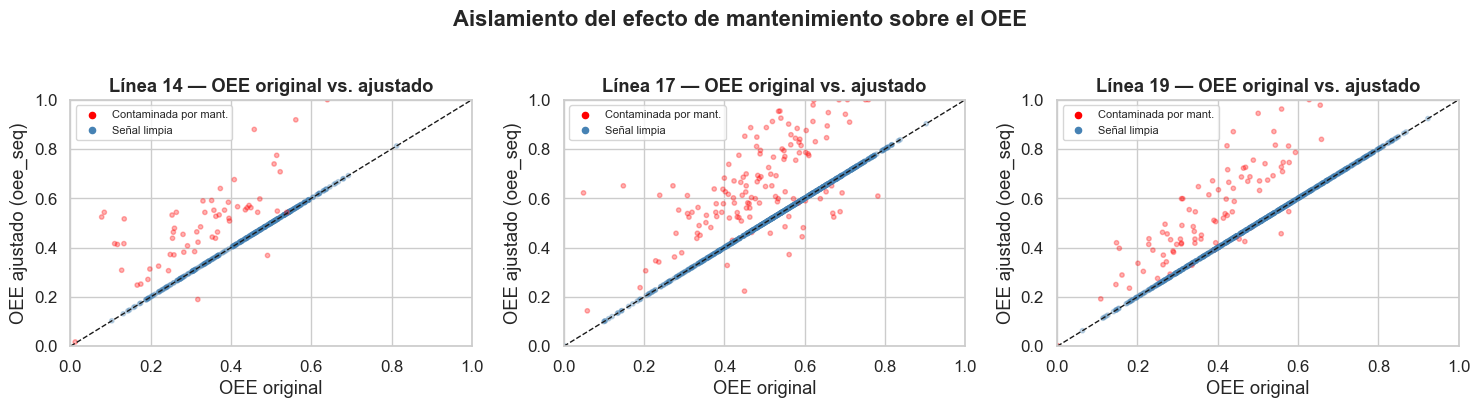

In [65]:
# Visualizar impacto del ajuste de mantenimiento en OEE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, line in zip(axes, ['14', '17', '19']):
    df_l = df_clean[df_clean['tren'] == line].copy()
    ax.scatter(df_l['oee'], df_l['oee_seq'], alpha=0.3, s=10,
               c=df_l['mant_contaminada'].map({True: 'red', False: 'steelblue'}))
    lims = [0, 1]
    ax.plot(lims, lims, 'k--', lw=1, label='Sin ajuste')
    ax.set_xlabel('OEE original')
    ax.set_ylabel('OEE ajustado (oee_seq)')
    ax.set_title(f'Línea {line} — OEE original vs. ajustado', fontweight='bold')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    red_patch = plt.scatter([], [], c='red', s=20, label='Contaminada por mant.')
    blue_patch = plt.scatter([], [], c='steelblue', s=20, label='Señal limpia')
    ax.legend(handles=[red_patch, blue_patch], fontsize=8)

plt.suptitle('Aislamiento del efecto de mantenimiento sobre el OEE', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3 · Matrices de transición por línea

[build_transition_matrices] Línea 14: 259 transiciones únicas (63 SKUs origen, 63 SKUs destino)
[build_transition_matrices] Línea 17: 517 transiciones únicas (76 SKUs origen, 75 SKUs destino)
[build_transition_matrices] Línea 19: 547 transiciones únicas (108 SKUs origen, 108 SKUs destino)


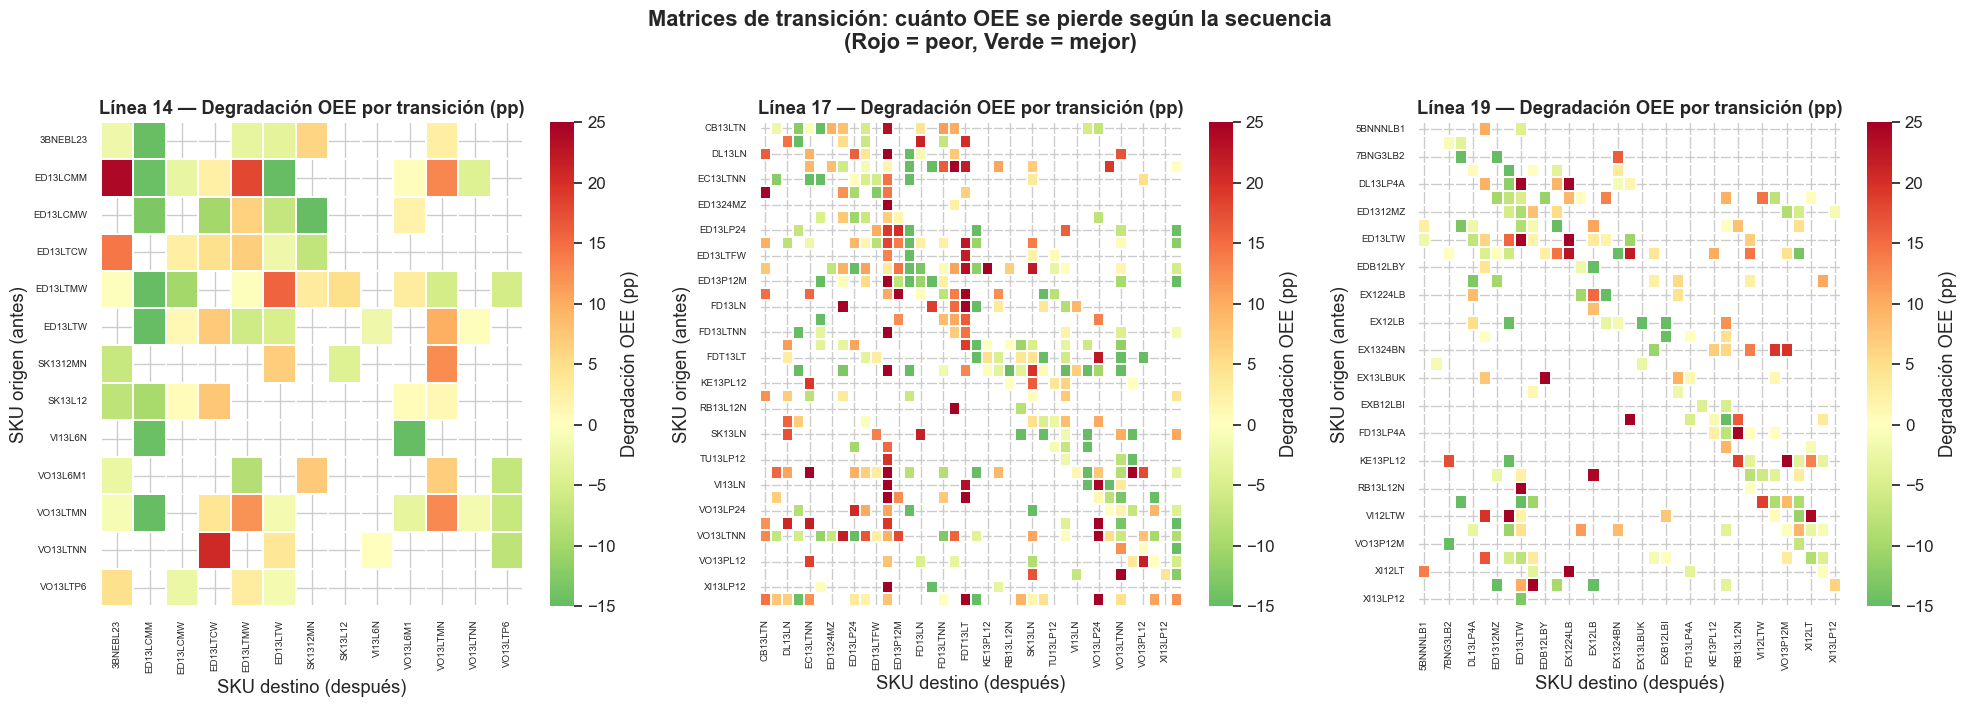

In [66]:
matrices = analyzer.build_transition_matrices()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, line in zip(axes, ['14', '17', '19']):
    if line not in matrices:
        ax.set_visible(False)
        continue
    mat = matrices[line]['oee_degradation']
    # Mostrar solo SKUs con al menos 5 transiciones como origen o destino
    raw = matrices[line]['_raw']
    active_skus = set(
        raw[raw['count'] >= 3]['sku_prev'].tolist() +
        raw[raw['count'] >= 3]['sku'].tolist()
    )
    mat_filt = mat.loc[
        [i for i in mat.index if i in active_skus],
        [c for c in mat.columns if c in active_skus]
    ]
    if mat_filt.empty:
        mat_filt = mat

    sns.heatmap(
        mat_filt * 100, ax=ax, cmap='RdYlGn_r',
        annot=len(mat_filt) <= 12, fmt='.1f',
        center=0, vmin=-15, vmax=25,
        cbar_kws={'label': 'Degradación OEE (pp)'},
        linewidths=0.3
    )
    ax.set_title(f'Línea {line} — Degradación OEE por transición (pp)', fontweight='bold')
    ax.set_xlabel('SKU destino (después)')
    ax.set_ylabel('SKU origen (antes)')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.suptitle('Matrices de transición: cuánto OEE se pierde según la secuencia\n(Rojo = peor, Verde = mejor)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.1 · Validacion del principio: revisar la OF anterior

In [67]:
seq_check = analyzer.get_sequences()
transitions_check = seq_check[~seq_check['es_primera_of_semana']].copy()
print(f"Transiciones con OF anterior: {len(transitions_check):,}")
print(f"Cobertura sku_prev: {transitions_check['sku_prev'].notna().mean():.1%}")
print("Ejemplo de nexo OF -> Cambio -> OEE limpio:")
cols = ['tren', 'year_week', 'of', 'sku_prev', 'sku', 'tipo_transicion', 'oee_seq']
print(transitions_check[cols].head(8).to_string(index=False))

Transiciones con OF anterior: 1,986
Cobertura sku_prev: 100.0%
Ejemplo de nexo OF -> Cambio -> OEE limpio:
tren             year_week           of sku_prev      sku        tipo_transicion  oee_seq
  14 2024-12-30/2025-01-05 0000520116-1 VI13LP6M VO13LTNN cambio_pack_secundario 0.317267
  14 2024-12-30/2025-01-05 0000520179-1 VO13LTNN  VI13L6N           cambio_palet 0.412940
  14 2025-01-06/2025-01-12 0000519449-1  ED12LTW  VI13L6N   cambio_pack_primario 0.370797
  14 2025-01-06/2025-01-12 0000520178-1  VI13L6N ED13LCMM          cambio_envase 0.416225
  14 2025-01-06/2025-01-12 0000526575-1 ED13LCMM VI13LP6M           cambio_palet 0.486623
  14 2025-01-06/2025-01-12 0000526576-1 VI13LP6M  XI13LTN cambio_pack_secundario 0.552223
  14 2025-01-06/2025-01-12 0000526687-1  XI13LTN ED13LCMW         cambio_cerveza 0.345156
  14 2025-01-06/2025-01-12 0000526689-1 ED13LCMW VO13L6M1           cambio_palet 0.292833


## 4 · Grafo dirigido de transiciones

In [68]:
graphs = analyzer.build_directed_graph()
for line, G in graphs.items():
    print(f"Línea {line}: {G.number_of_nodes()} nodos · {G.number_of_edges()} aristas")


[build_directed_graph] Línea 14: 66 nodos, 259 aristas
[build_directed_graph] Línea 17: 76 nodos, 517 aristas
[build_directed_graph] Línea 19: 111 nodos, 547 aristas
Línea 14: 66 nodos · 259 aristas
Línea 17: 76 nodos · 517 aristas
Línea 19: 111 nodos · 547 aristas


## 5 · Nodos críticos — métricas topológicas

In [69]:
for line in ['14', '17', '19']:
    if line not in graphs:
        continue
    G = graphs[line]
    node_df = pd.DataFrame([
        {
            'SKU': n,
            'Betweenness': attrs.get('betweenness', 0),
            'In-deg ponderado (degradación recibida)': attrs.get('in_deg_weighted', 0),
            'Out-deg ponderado (degradación causada)': attrs.get('out_deg_weighted', 0),
            'PageRank': attrs.get('pagerank', 0),
        }
        for n, attrs in G.nodes(data=True)
    ]).sort_values('In-deg ponderado (degradación recibida)', ascending=False)

    print(f"\n{'='*60}")
    print(f"  LÍNEA {line} — Top nodos críticos (destructores de ritmo)")
    print(f"{'='*60}")
    print(node_df.head(8).to_string(index=False, float_format='{:.4f}'.format))


  LÍNEA 14 — Top nodos críticos (destructores de ritmo)
     SKU  Betweenness  In-deg ponderado (degradación recibida)  Out-deg ponderado (degradación causada)  PageRank
ED13LTCW       0.1873                                   0.6591                                  -0.1517    0.0152
LC13LTNN       0.0625                                   0.3838                                      NaN    0.0152
VI13L6AU       0.0669                                   0.3790                                   0.2959    0.0152
3BNEBL23       0.4925                                   0.3657                                  -0.2920    0.0152
3BVMLLB0       0.0034                                   0.2242                                      NaN    0.0152
 VI13LTX       0.0017                                   0.2042                                  -0.0953    0.0152
 VI13L6N       0.0163                                   0.1212                                  -0.1569    0.0152
EX13LTBA       0.1553          

## 6 · Black Spots — transiciones sistemáticamente destructivas

In [70]:
black_spots = analyzer.detect_black_spots()
print(f"Black spots detectados: {len(black_spots)}")
print()

# Mostrar top 15
display_cols = ['tren', 'sku_prev', 'sku', 'tipo_transicion',
                'oee_mean', 'oee_degradation', 'count',
                'changeover_h_mean', 'hl_perdidos_estimados', 'gravedad']
available = [c for c in display_cols if c in black_spots.columns]
print(black_spots[available].head(15).to_string(index=False, float_format='{:.3f}'.format))

[detect_black_spots] 20 black spots detectados (umbral degradación > μ + 1.5σ, mín. 2 ocurrencias)
Black spots detectados: 20

tren sku_prev      sku        tipo_transicion  oee_mean  oee_degradation  count  changeover_h_mean  hl_perdidos_estimados gravedad
  17 XI13L12M VO13LTNN cambio_pack_secundario     0.316            0.317      2                NaN               1806.293  crítica
  17 ED1324MZ  ED13LTW cambio_pack_secundario     0.316            0.450      2              1.808               1454.814  crítica
  14 ED13LTMW  ED13LTW         cambio_cerveza     0.357            0.157      3              1.167               1035.174     alta
  17   FD13LN  FDT13LT         cambio_cerveza     0.530            0.251      4              1.895                823.683  crítica
  17 ED13P12M  ED13LTW cambio_pack_secundario     0.513            0.252      2              0.973                815.950  crítica
  19 EX25L10A EX25LBAN cambio_pack_secundario     0.398            0.196      2        

In [71]:
## Grafo interactivo Bokeh — un plot por línea
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, LabelSet, Range1d
from bokeh.layouts import column as bk_column
import numpy as np

output_notebook()

# ── helpers ──────────────────────────────────────────────────────────────────

def _bezier(x0, y0, x1, y1, k=0.22, n=30):
    """Quadratic bezier — control point offset perpendicular to edge."""
    dx, dy = x1 - x0, y1 - y0
    norm = max((dx**2 + dy**2) ** 0.5, 1e-9)
    cx = (x0 + x1) / 2 + k * (-dy) / norm
    cy = (y0 + y1) / 2 + k * dx  / norm
    t  = np.linspace(0, 1, n)
    bx = (1-t)**2 * x0 + 2*(1-t)*t * cx + t**2 * x1
    by = (1-t)**2 * y0 + 2*(1-t)*t * cy + t**2 * y1
    return bx.tolist(), by.tolist()


def bokeh_graph(G, line, bs_df=None, min_obs=2, width=800, height=680):
    """
    Interactive Bokeh directed-graph figure for SKU transition analysis.
    Nodes  : sized by betweenness centrality; red if involved in a black spot.
    Edges  : curved bezier; red/thick = OEE degradation > 5 pp.
    Arrows : small triangles at 85% of each edge to indicate direction.
    Hover  : SKU, estado, betweenness, in/out-degree weighted, PageRank.
    """
    Gf = nx.DiGraph()
    for u, v, d in G.edges(data=True):
        if d.get('count', 0) >= min_obs:
            Gf.add_edge(u, v, **d)
    if Gf.number_of_nodes() == 0:
        Gf = G.copy()

    pos = nx.spring_layout(Gf, seed=42, k=2.8)

    bs_skus = set()
    if bs_df is not None and not bs_df.empty:
        sub = bs_df[bs_df['tren'] == line]
        if not sub.empty:
            bs_skus = set(sub['sku_prev'].tolist() + sub['sku'].tolist())

    bc  = nx.get_node_attributes(Gf, 'betweenness')
    idw = nx.get_node_attributes(Gf, 'in_deg_weighted')
    odw = nx.get_node_attributes(Gf, 'out_deg_weighted')
    pr  = nx.get_node_attributes(Gf, 'pagerank')

    nodes  = list(Gf.nodes())
    # 'or 1e-9' guards against all-zero betweenness (max() returns 0, not default)
    max_bc = max((bc.get(n, 0) for n in nodes), default=0) or 1e-9

    node_src = ColumnDataSource({
        'x':     [pos[n][0] for n in nodes],
        'y':     [pos[n][1] for n in nodes],
        'name':  nodes,
        'size':  [max(12, min(50, 12 + 38 * bc.get(n, 0) / max_bc)) for n in nodes],
        'color': ['#e74c3c' if n in bs_skus else '#2980b9'           for n in nodes],
        'alpha': [1.0       if n in bs_skus else 0.85                for n in nodes],
        'bc':    [f"{bc.get(n,  0):.4f}" for n in nodes],
        'idw':   [f"{idw.get(n, 0):.4f}" for n in nodes],
        'odw':   [f"{odw.get(n, 0):.4f}" for n in nodes],
        'pr':    [f"{pr.get(n,  0):.4f}" for n in nodes],
        'tipo':  ['⚠ BLACK SPOT' if n in bs_skus else 'Normal'      for n in nodes],
    })

    xs, ys, ec, ew, ax_arr, ay_arr, aa, ac = [], [], [], [], [], [], [], []
    for u, v, d in Gf.edges(data=True):
        bx, by = _bezier(*pos[u], *pos[v])
        xs.append(bx); ys.append(by)
        w   = d.get('weight', 0)
        col = '#e74c3c' if w > 0.05 else '#aab7b8'
        ec.append(col); ew.append(max(0.8, abs(w) * 14))
        i = int(0.85 * len(bx))
        ax_arr.append(bx[i]); ay_arr.append(by[i])
        aa.append(float(np.arctan2(by[i] - by[i-1], bx[i] - bx[i-1])))
        ac.append(col)

    edge_src  = ColumnDataSource({'xs': xs, 'ys': ys, 'col': ec, 'w': ew})
    arrow_src = ColumnDataSource({'x': ax_arr, 'y': ay_arr, 'angle': aa, 'col': ac})

    show_nodes = [n for n in nodes if bc.get(n, 0) > max_bc * 0.12 or n in bs_skus]
    lbl_src = ColumnDataSource({
        'x': [pos[n][0] for n in show_nodes],
        'y': [pos[n][1] for n in show_nodes],
        'name': show_nodes,
    })

    p = figure(
        title=(f"Línea {line}  ·  Grafo dirigido SKU"
               f"  ({Gf.number_of_nodes()} nodos · {Gf.number_of_edges()} aristas"
               f"  |  ● rojo = black spot)"),
        width=width, height=height,
        tools="pan,wheel_zoom,box_zoom,reset,save",
        toolbar_location="above",
        x_range=Range1d(-2.2, 2.2),
        y_range=Range1d(-2.2, 2.2),
    )
    p.axis.visible = False
    p.grid.visible = False
    p.outline_line_color = None
    p.background_fill_color = "#f8f9fa"
    p.title.text_font_size = "10pt"

    p.multi_line('xs', 'ys', source=edge_src,
                 line_color='col', line_width='w',
                 line_alpha=0.5, line_cap='round')
    p.triangle('x', 'y', source=arrow_src,
               size=8, angle='angle', angle_units='rad',
               fill_color='col', line_color=None, fill_alpha=0.7)
    circles = p.circle('x', 'y', source=node_src,
                        size='size', fill_color='color', fill_alpha='alpha',
                        line_color='white', line_width=1.5)
    p.add_tools(HoverTool(renderers=[circles], tooltips=[
        ('SKU',                  '@name'),
        ('Estado',               '@tipo'),
        ('Betweenness',          '@bc'),
        ('Degradación recibida', '@idw'),
        ('Degradación causada',  '@odw'),
        ('PageRank',             '@pr'),
    ]))
    p.add_layout(LabelSet(
        x='x', y='y', text='name', source=lbl_src,
        x_offset=9, y_offset=5,
        text_font_size='7pt', text_color='#1a252f', text_font_style='bold',
    ))
    return p


# ── render: 1 figura interactiva por línea ────────────────────────────────────
figs = [
    bokeh_graph(graphs[line], line, bs_df=black_spots)
    for line in ['14', '17', '19']
    if line in graphs and graphs[line].number_of_nodes() > 0
]
show(bk_column(*figs, sizing_mode='stretch_width'))


Loading BokehJS ...

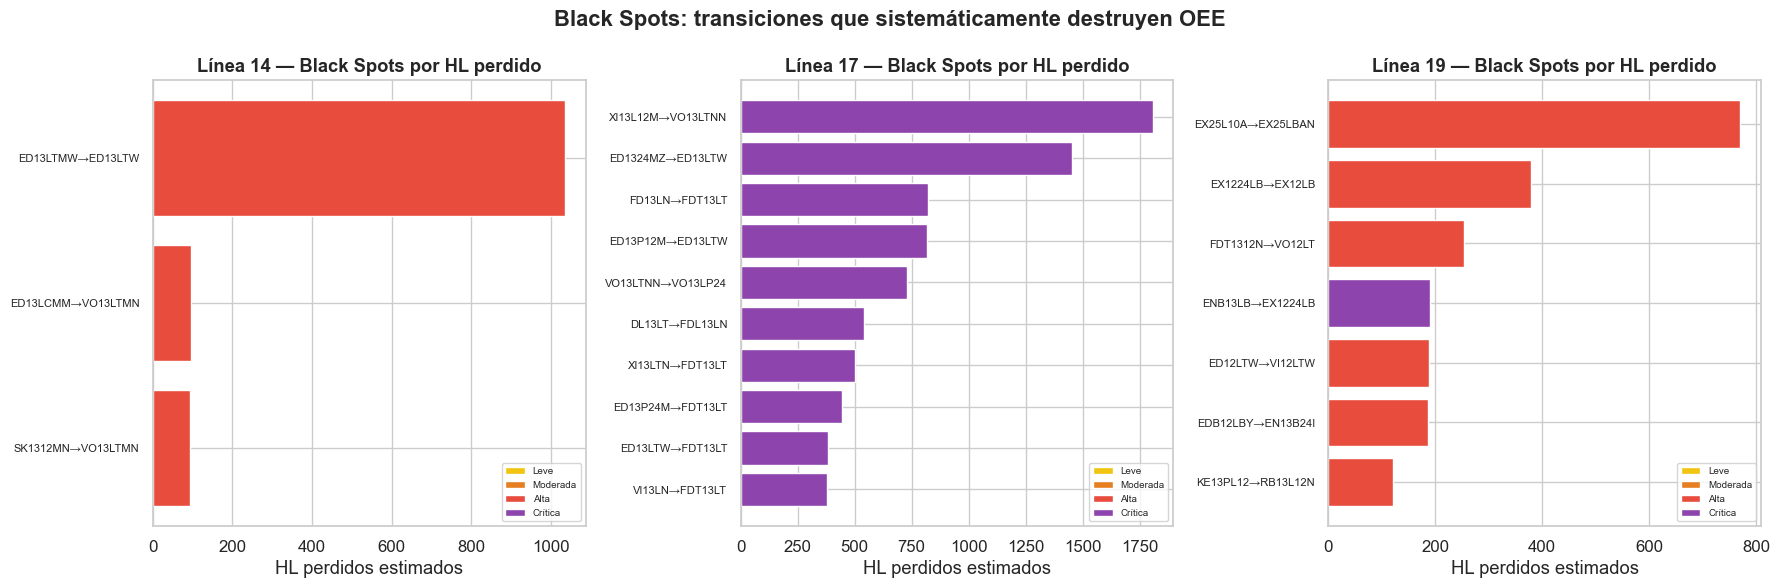

In [72]:
# Visualización black spots por línea
if not black_spots.empty and 'hl_perdidos_estimados' in black_spots.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    _color_map = {'leve': '#f1c40f', 'moderada': '#e67e22', 'alta': '#e74c3c', 'crítica': '#8e44ad'}

    for ax, line in zip(axes, ['14', '17', '19']):
        bs_l = black_spots[black_spots['tren'] == line].head(10)
        if bs_l.empty:
            ax.text(0.5, 0.5, 'Sin black spots', ha='center', va='center')
            ax.set_title(f'Línea {line}', fontweight='bold')
            continue

        labels = bs_l.apply(lambda r: f"{r['sku_prev'][:8]}→{r['sku'][:8]}", axis=1)
        # astype(str) avoids Categorical dtype issue with fillna
        colors = bs_l['gravedad'].astype(str).map(_color_map).fillna('#95a5a6')

        ax.barh(range(len(bs_l)), bs_l['hl_perdidos_estimados'],
                color=colors, edgecolor='white')
        ax.set_yticks(range(len(bs_l)))
        ax.set_yticklabels(labels, fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('HL perdidos estimados')
        ax.set_title(f'Línea {line} — Black Spots por HL perdido', fontweight='bold')

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(fc='#f1c40f', label='Leve'),    Patch(fc='#e67e22', label='Moderada'),
            Patch(fc='#e74c3c', label='Alta'),     Patch(fc='#8e44ad', label='Crítica'),
        ]
        ax.legend(handles=legend_elements, fontsize=7, loc='lower right')

    plt.suptitle('Black Spots: transiciones que sistemáticamente destruyen OEE', fontweight='bold')
    plt.tight_layout()
    plt.show()


## 7 · Métricas de explicabilidad — tabla resumen final

In [73]:
metrics = analyzer.export_explainability_metrics()

print("\n" + "="*65)
print("  TOP 10 PEORES TRANSICIONES (para presentar al jurado)")
print("="*65)
print(metrics['top_black_spots'].to_string(index=False))

print("\n" + "="*65)
print("  RESUMEN POR LÍNEA")
print("="*65)
print(metrics['line_summary'].to_string(index=False))

print("\n" + "="*65)
print("  NODOS MÁS CRÍTICOS DEL GRAFO")
print("="*65)
print(metrics['critical_nodes'].head(10).to_string(index=False))

[export_explainability_metrics] Métricas de explicabilidad generadas:
  · top_black_spots: 10 filas
  · critical_nodes: 20 filas
  · weekly_oee_loss: 152 filas
  · line_summary: 3 filas

  TOP 10 PEORES TRANSICIONES (para presentar al jurado)
Línea SKU origen SKU destino            Tipo cambio  OEE medio resultante  Degradación OEE  Veces ocurrido  Changeover medio (h)  HL perdidos estimados Gravedad
   17   XI13L12M    VO13LTNN cambio_pack_secundario              0.316383         0.317446               2                   NaN            1806.292867  crítica
   17   ED1324MZ     ED13LTW cambio_pack_secundario              0.315517         0.450021               2              1.807778            1454.814494  crítica
   14   ED13LTMW     ED13LTW         cambio_cerveza              0.357453         0.157114               3              1.166636            1035.174475     alta
   17     FD13LN     FDT13LT         cambio_cerveza              0.529501         0.250857               4       

## 8 · Análisis semanal — evolución del OEE a lo largo del año

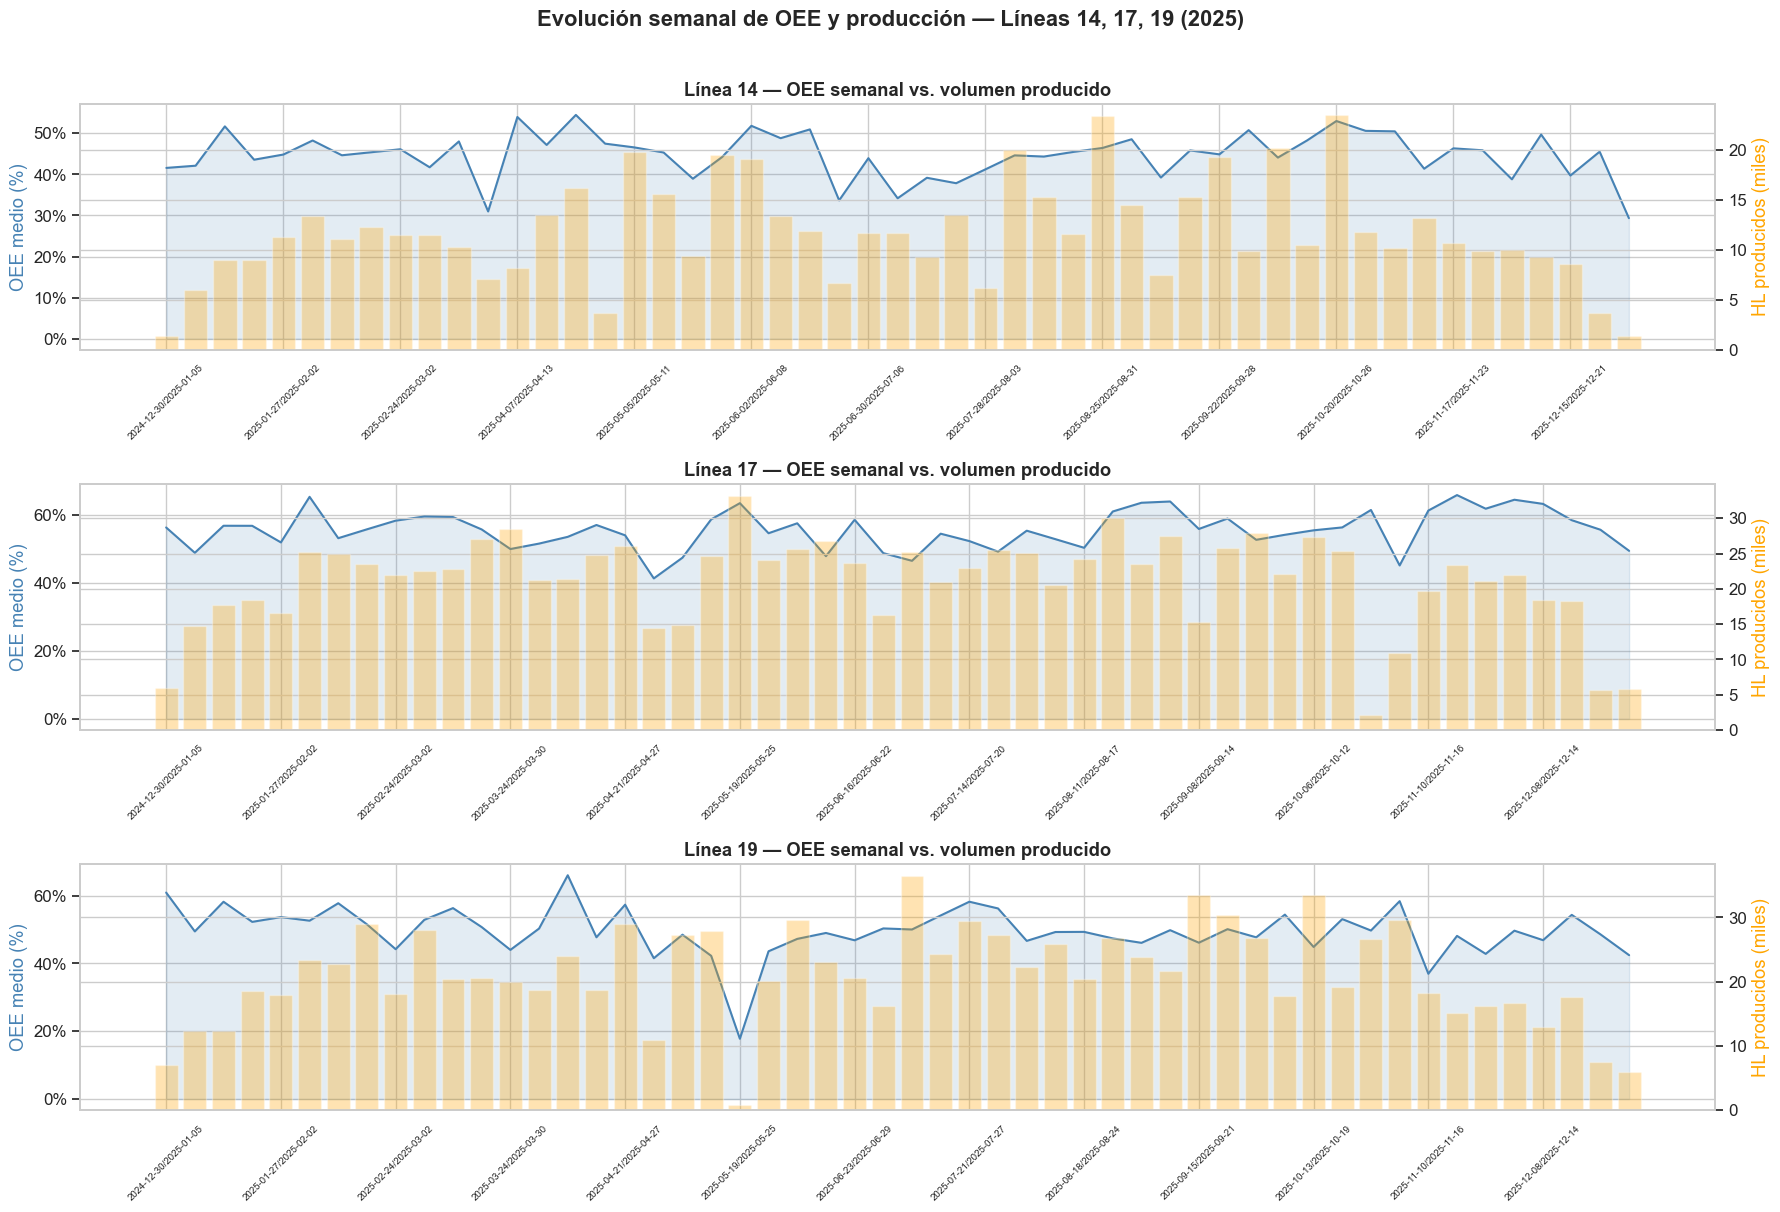

In [74]:
seq = analyzer.get_sequences()
seq['year_week_str'] = seq['year_week'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=False)

for ax, line in zip(axes, ['14', '17', '19']):
    df_l = seq[seq['tren'] == line].copy()
    weekly = df_l.groupby('year_week').agg(
        oee_medio=('oee_seq', 'mean'),
        n_transiciones=('es_primera_of_semana', lambda x: (~x).sum()),
        hl_total=('hl', 'sum'),
    ).reset_index()
    weekly['semana'] = weekly['year_week'].astype(str)

    ax2 = ax.twinx()
    ax.plot(range(len(weekly)), weekly['oee_medio'] * 100, color='steelblue', lw=1.5, label='OEE semanal')
    ax.fill_between(range(len(weekly)), weekly['oee_medio'] * 100, alpha=0.15, color='steelblue')
    ax2.bar(range(len(weekly)), weekly['hl_total'] / 1000, alpha=0.3, color='orange', label='HL (miles)')

    ax.set_ylabel('OEE medio (%)', color='steelblue')
    ax2.set_ylabel('HL producidos (miles)', color='orange')
    ax.set_title(f'Línea {line} — OEE semanal vs. volumen producido', fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))

    # Marcar semanas con black spots
    if not black_spots.empty:
        bs_weeks_l = set()
        # aquí simplificamos: no tenemos la semana directa en black_spots,
        # pero podemos aproximar con las semanas de las secuencias
        pass

    # Mostrar solo cada 4 semanas en eje X
    ticks = range(0, len(weekly), 4)
    ax.set_xticks(list(ticks))
    ax.set_xticklabels([weekly['semana'].iloc[i] for i in ticks], rotation=45, fontsize=7)

plt.suptitle('Evolución semanal de OEE y producción — Líneas 14, 17, 19 (2025)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9 · Modelo de Grafos Sofisticado: Suavizado Bilinear sobre la Red de SKUs

Para solventar la escasez de transiciones históricas (las matrices son muy dispersas), implementamos un suavizado bilinear kernel sobre el grafo de similitud de SKUs. Esto nos da estimaciones de degradación de OEE y tiempos de cambio para cualquier transición basadas en el comportamiento de SKUs similares.

In [ ]:
from analisis_postmorten.sophisticated_graph import SophisticatedGraphModel

# Seleccionar una muestra de SKUs históricos
skus_test = df_clean['sku'].dropna().unique().tolist()[:10]

sg_model = SophisticatedGraphModel(df_oee=df_clean)
smoothed_mats = analyzer.build_sophisticated_matrices(skus_test)

# Graficar matrices original vs. suavizada para Línea 17
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz original
mat_orig = matrices['17']['oee_degradation'].reindex(index=skus_test, columns=skus_test)
sns.heatmap(mat_orig * 100, ax=axes[0], cmap='RdYlGn_r', center=0, annot=True, fmt='.1f')
axes[0].set_title('Degradación OEE Original L17 (pp) - Muy dispersa')

# Matriz suavizada
mat_smooth = smoothed_mats['17']['oee_degradation'].reindex(index=skus_test, columns=skus_test)
sns.heatmap(mat_smooth * 100, ax=axes[1], cmap='RdYlGn_r', center=0, annot=True, fmt='.1f')
axes[1].set_title('Degradación OEE Suavizada por Grafo L17 (pp) - Cobertura Completa')

plt.tight_layout()
plt.show()

In [ ]:
# Demostración de explicabilidad del modelo de grafos suavizado
u, v = skus_test[0], skus_test[1]
explanation = smoothed_mats['17']['model'].explain_estimated_transition('17', u, v, matrices)

print(f"Explicabilidad de la transición estimada: {u} -> {v}")
print(f"  Tipo de estimación: {explanation['explanation_type']}")
print(f"  Degradación OEE estimada: {explanation['estimated_oee_degradation'] * 100:.2f} pp")
print(f"  Duración de cambio estimada: {explanation['estimated_changeover_h']:.2f} horas")

if explanation['top_contributing_transitions']:
    print("\nTop transiciones históricas similares que justifican este coste:")
    for contrib in explanation['top_contributing_transitions']:
        print(f"  · Histórica: {contrib['historical_transition']} | Similitud: {contrib['bilinear_weight']:.2f} | Degradación: {contrib['oee_degradation']*100:.2f} pp")